In [2]:
from pandas_datareader import data, wb
import pandas as pd
import numpy as np
import datetime
%matplotlib inline

In [3]:
start = datetime.datetime(2006, 1, 1)
end = datetime.datetime(2016, 1, 1)

In [6]:
import yfinance as yf
start = "2006-01-01"
end = "2016-01-01"
BAC = yf.download("BAC", start=start, end=end)
C = yf.download("C", start=start, end=end)
GS = yf.download("GS", start=start, end=end)
JPM = yf.download("JPM", start=start, end=end)
MS = yf.download("MS", start=start, end=end)
WFC = yf.download("WFC", start=start, end=end)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [11]:
df = pd.concat([BAC, C, GS, JPM, MS, WFC], axis=1)
df = df.swaplevel(axis=1).sort_index(axis=1)
df.columns.names = ['Bank Ticker', 'Stock Info']

In [12]:
df.head()

Bank Ticker        BAC                                                      C  \
Stock Info       Close       High        Low       Open    Volume       Close   
Date                                                                            
2006-01-03   30.330347  30.394769  29.731213  30.227268  16296700  314.316742   
2006-01-04   30.008223  30.433414  29.924472  30.278798  17757900  308.513794   
2006-01-05   30.046883  30.169288  29.840729  30.008230  14970700  310.044312   
2006-01-06   30.001793  30.220831  29.860062  30.149966  12599800  310.044312   
2006-01-09   30.021124  30.259491  29.866510  30.098433  15619400  308.577515   

Bank Ticker                                               ...         MS  \
Stock Info         High         Low        Open   Volume  ...      Close   
Date                                                      ...              
2006-01-03   314.890658  306.792023  312.467449  1537600  ...  31.182058   
2006-01-04   313.105160  308.322495  311.574711  1870960  ...  31.203432   
2006-01-05   311.064598  308.641388  308.896460  1143160  ...  31.289001   
2006-01-06   311.829832  307.366011  311.702287  1370210  ...  31.321081   
2006-01-09   310.809425  308.003599  309.916665  1680740  ...  31.652651   

Bank Ticker                                                  WFC             \
Stock Info        High        Low       Open   Volume      Close       High   
Date                                                                          
2006-01-03   31.278316  30.342480  30.572426  5377000  18.274660  18.317626   
2006-01-04   31.700762  31.203432  31.390600  7977800  18.062700  18.228833   
2006-01-05   31.331784  31.026969  31.310392  5778000  18.042654  18.077026   
2006-01-06   31.470814  31.043004  31.428034  6889800  18.148630  18.203053   
2006-01-09   31.706128  31.347836  31.353185  4144500  18.145761  18.231693   

Bank Ticker                                  
Stock Info         Low       Open    Volume  
Date                                         
2006-01-03   17.870784  18.102799  11016400  
2006-01-04   17.968176  18.217375  10870000  
2006-01-05   17.936672  18.045518  10158000  
2006-01-06   17.979632  18.091343   8403800  
2006-01-09   18.077017  18.145761   5619600  

[5 rows x 30 columns]

In [13]:
df.xs(key='Close',axis=1,level='Stock Info').max()

Bank Ticker
BAC     36.679710
C      374.732544
GS     181.499512
JPM     52.581120
MS      48.881317
WFC     43.081257
dtype: float64

In [14]:
returns = pd.DataFrame()

In [16]:
for tick in tickers:
    returns[tick+' Return'] = df[tick]['Close'].pct_change()
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010621,-0.018462,-0.013812,-0.005772,0.000685,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003028,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874
2006-01-09,0.000644,-0.004731,0.012030,0.016243,0.010586,-0.000158


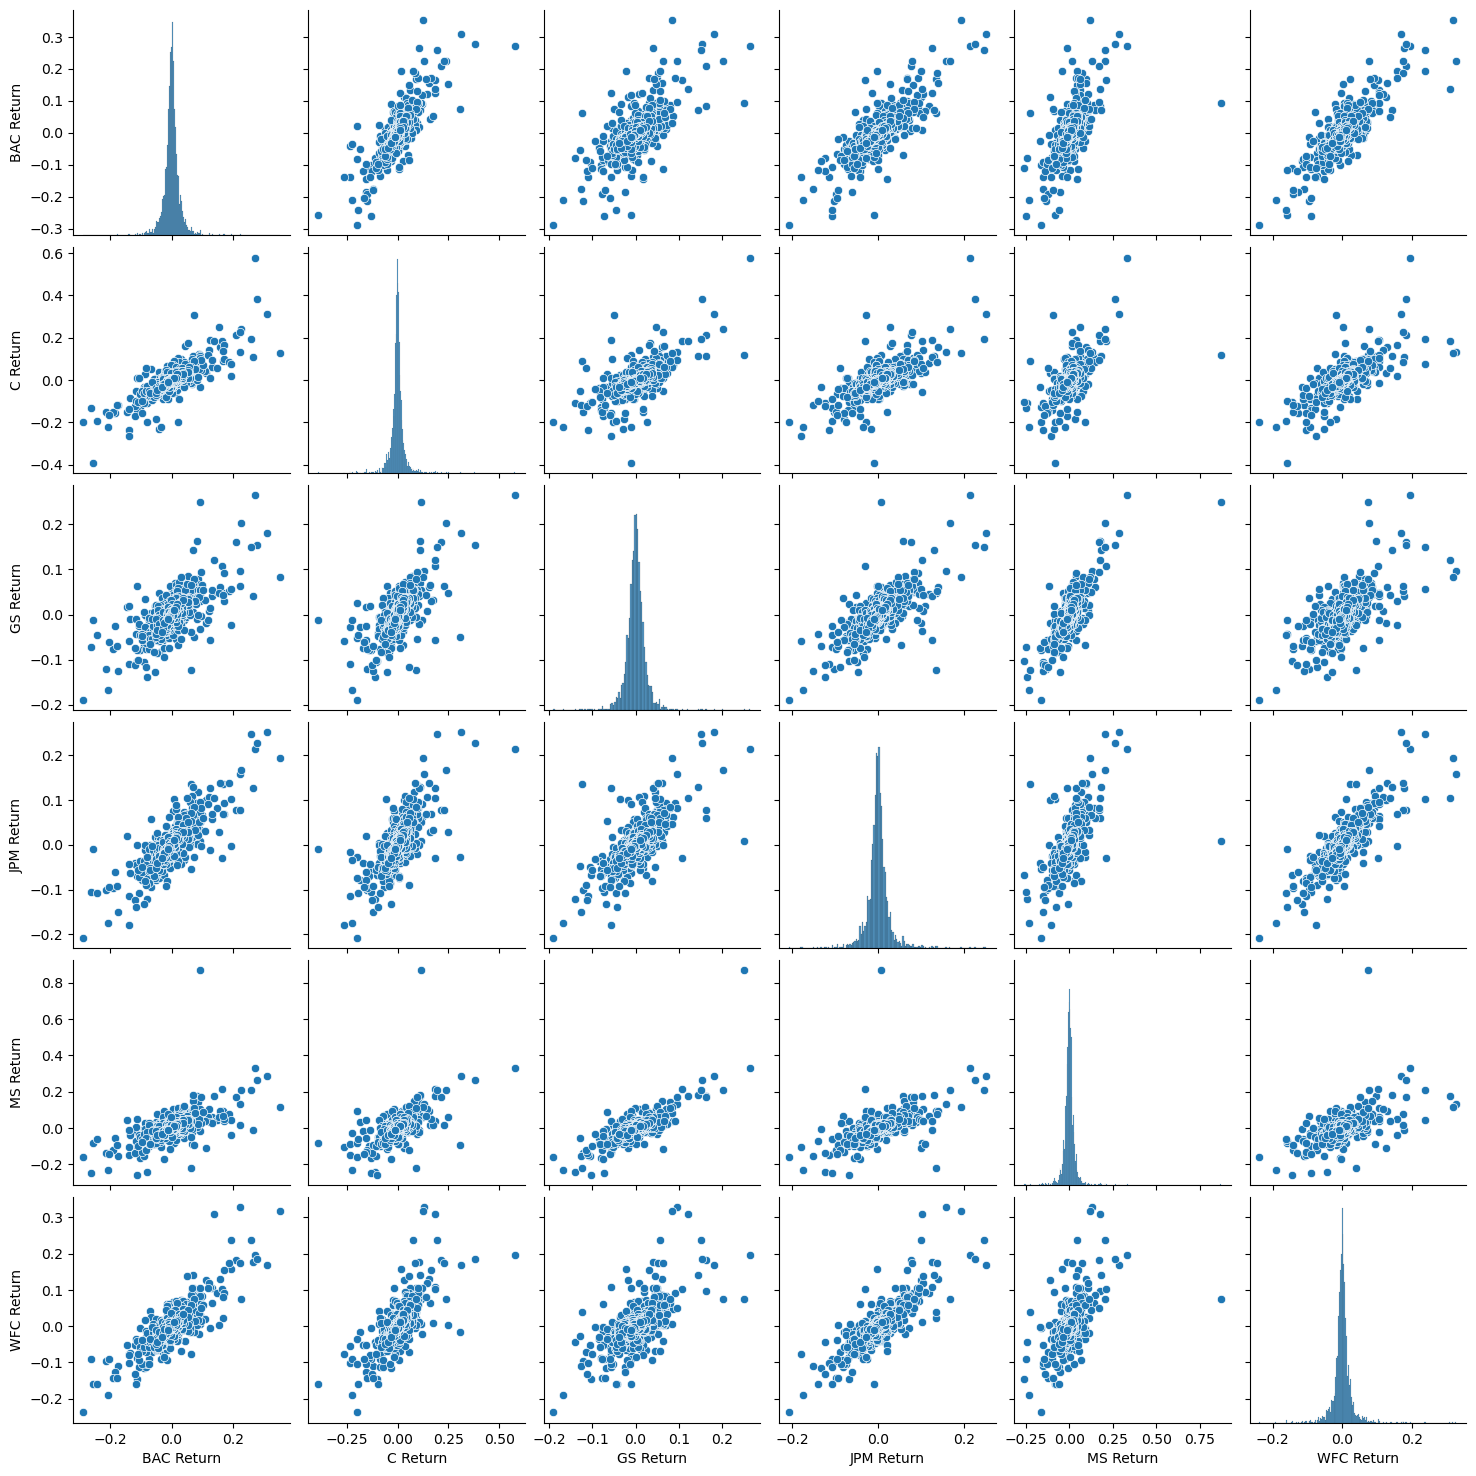

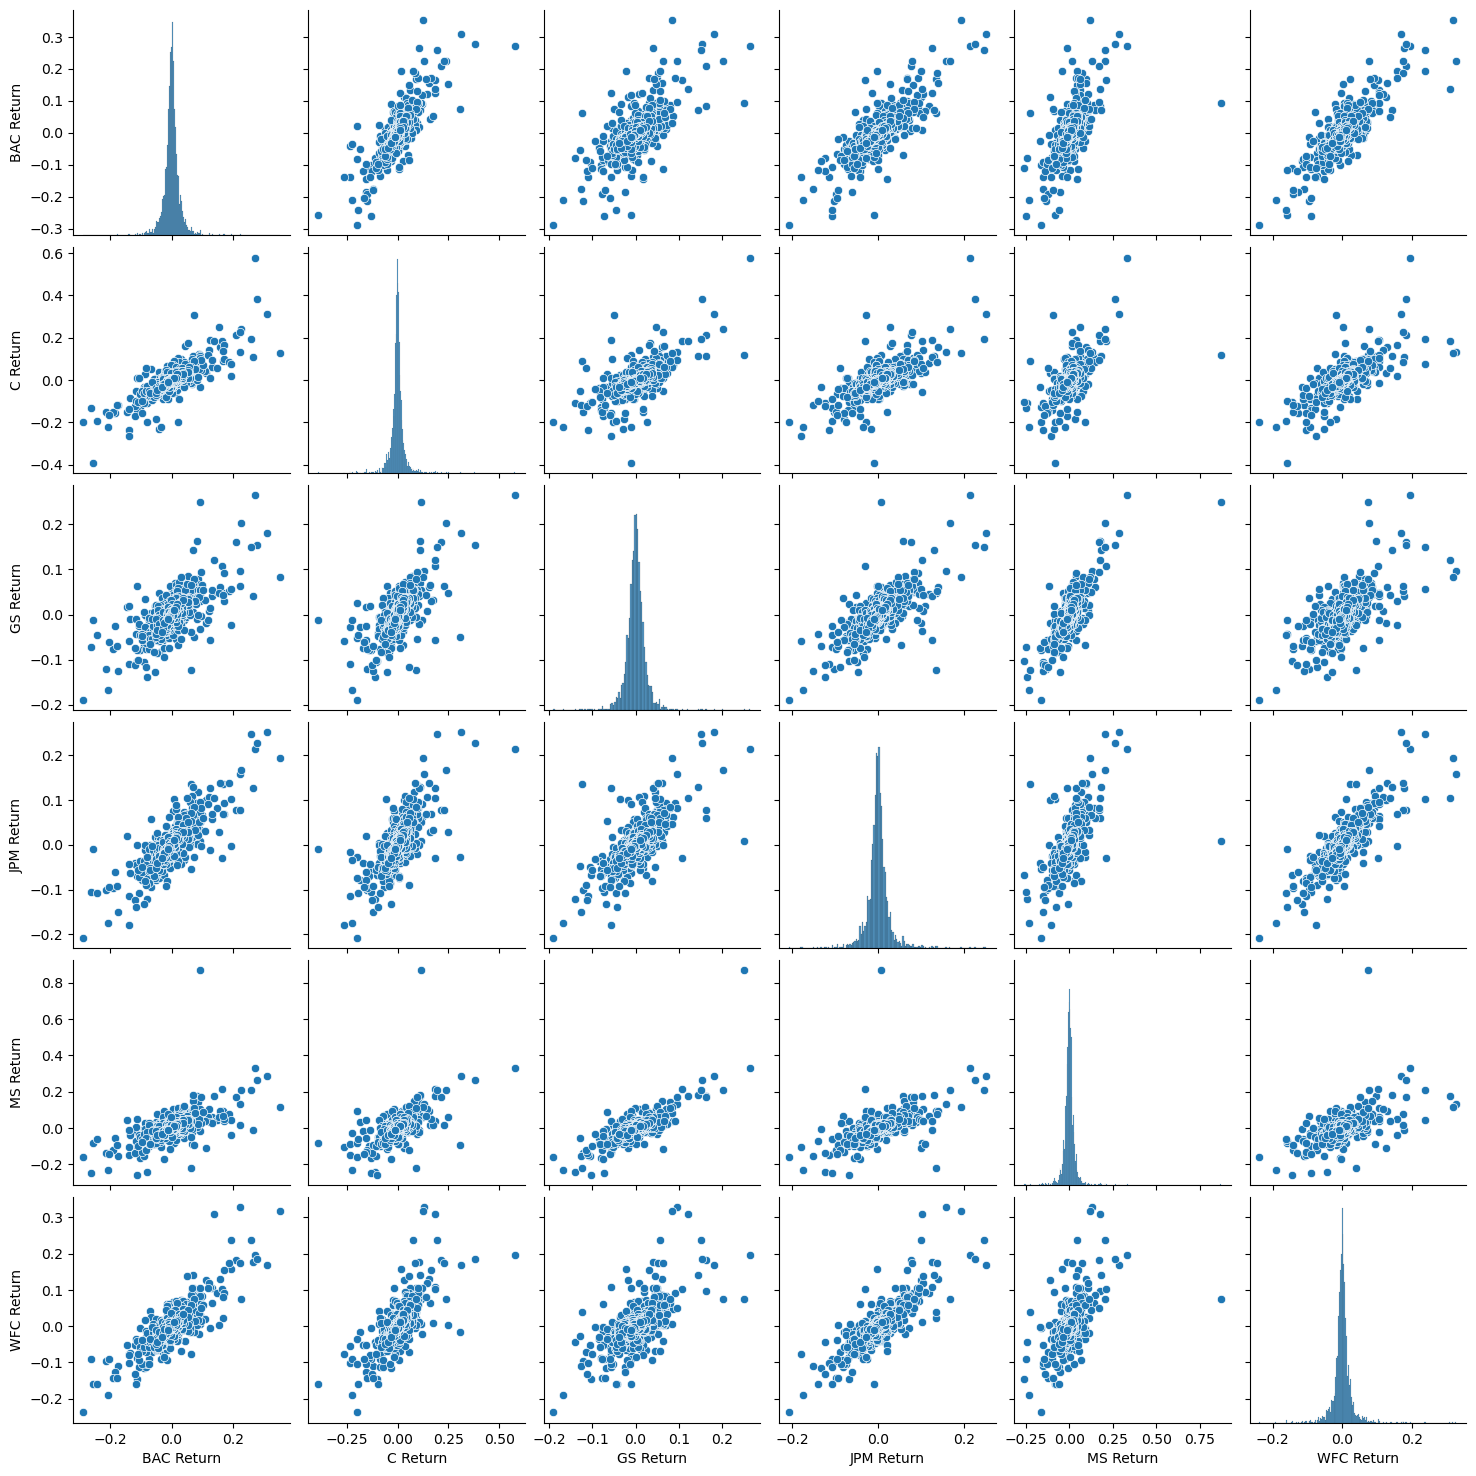

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(returns[1:])
plt.show()

In [19]:
returns.idxmin()

BAC Return   2009-01-20
C Return     2009-02-27
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
dtype: datetime64[ns]

In [20]:
returns.std()

BAC Return    0.036659
C Return      0.038672
GS Return     0.025386
JPM Return    0.027675
MS Return     0.037717
WFC Return    0.030195
dtype: float64

In [22]:
returns.loc['2015-01-01':'2015-12-31'].std()

BAC Return    0.016174
C Return      0.015288
GS Return     0.014043
JPM Return    0.014006
MS Return     0.016287
WFC Return    0.012552
dtype: float64

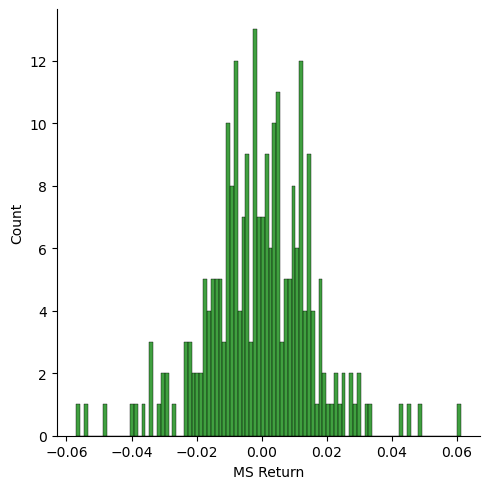

In [24]:
sns.displot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],color='green',bins=100)
plt.show()

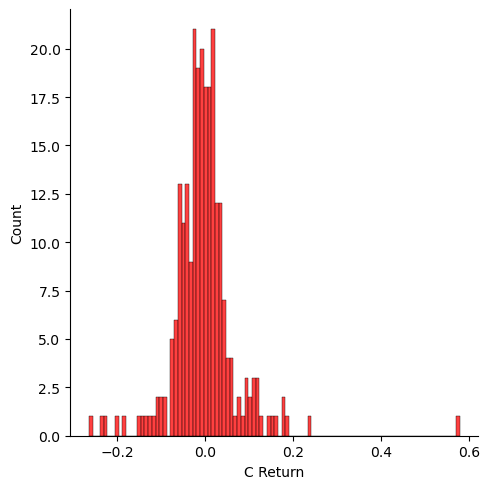

In [25]:
sns.displot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=100)
plt.show()

In [26]:
sns.set_style('whitegrid')

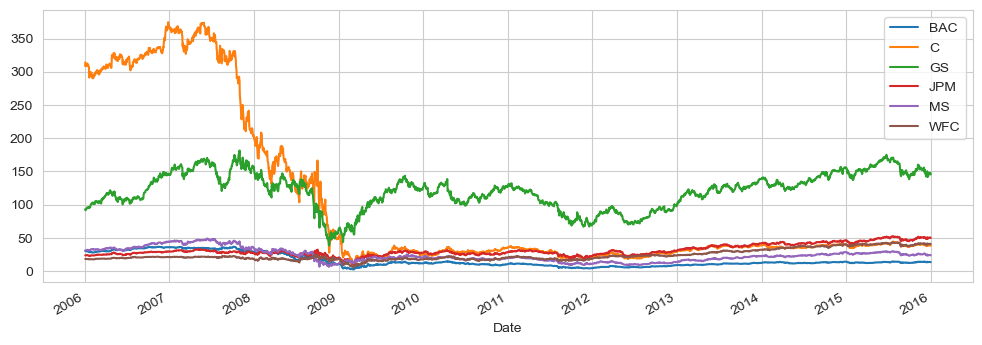

In [27]:
for tick in tickers:
    df[tick]['Close'].plot(figsize=(12,4),label=tick)
plt.legend()
plt.show()

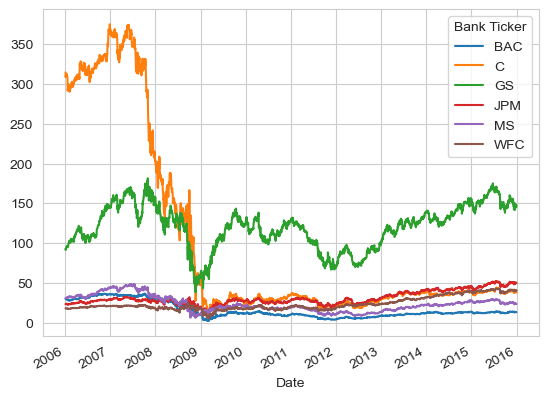

In [28]:
df.xs(key='Close',axis=1,level='Stock Info').plot()
plt.show()

<Figure size 1200x600 with 0 Axes>

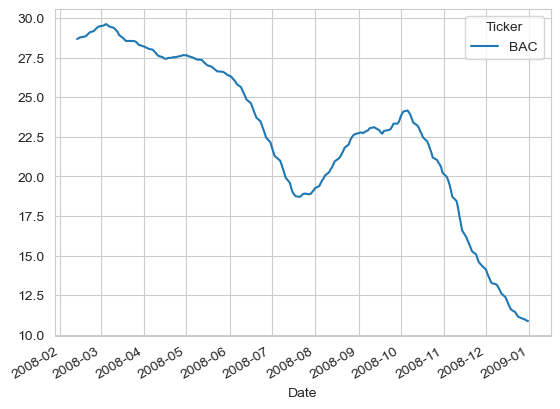

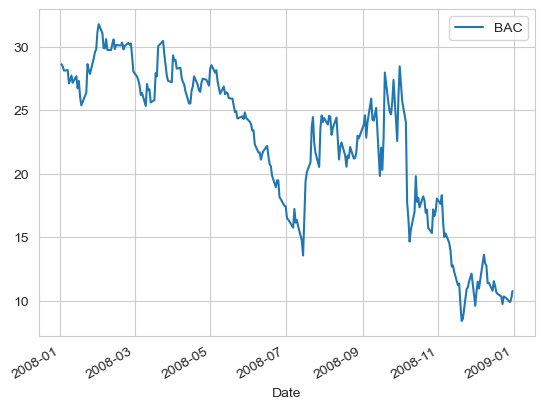

In [31]:
plt.figure(figsize=(12,6))
BAC['Close'].loc['2008-01-01':'2009-01-01'].rolling(window=30).mean().plot(label='30 Day Avg')
BAC['Close'].loc['2008-01-01':'2009-01-01'].plot(label='BAC CLOSE')
plt.legend()
plt.show()

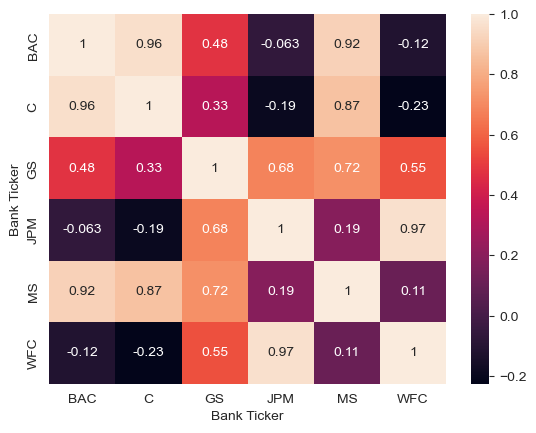

In [34]:
sns.heatmap(df.xs(key='Close',axis=1,level='Stock Info').corr(),annot=True)
plt.show()

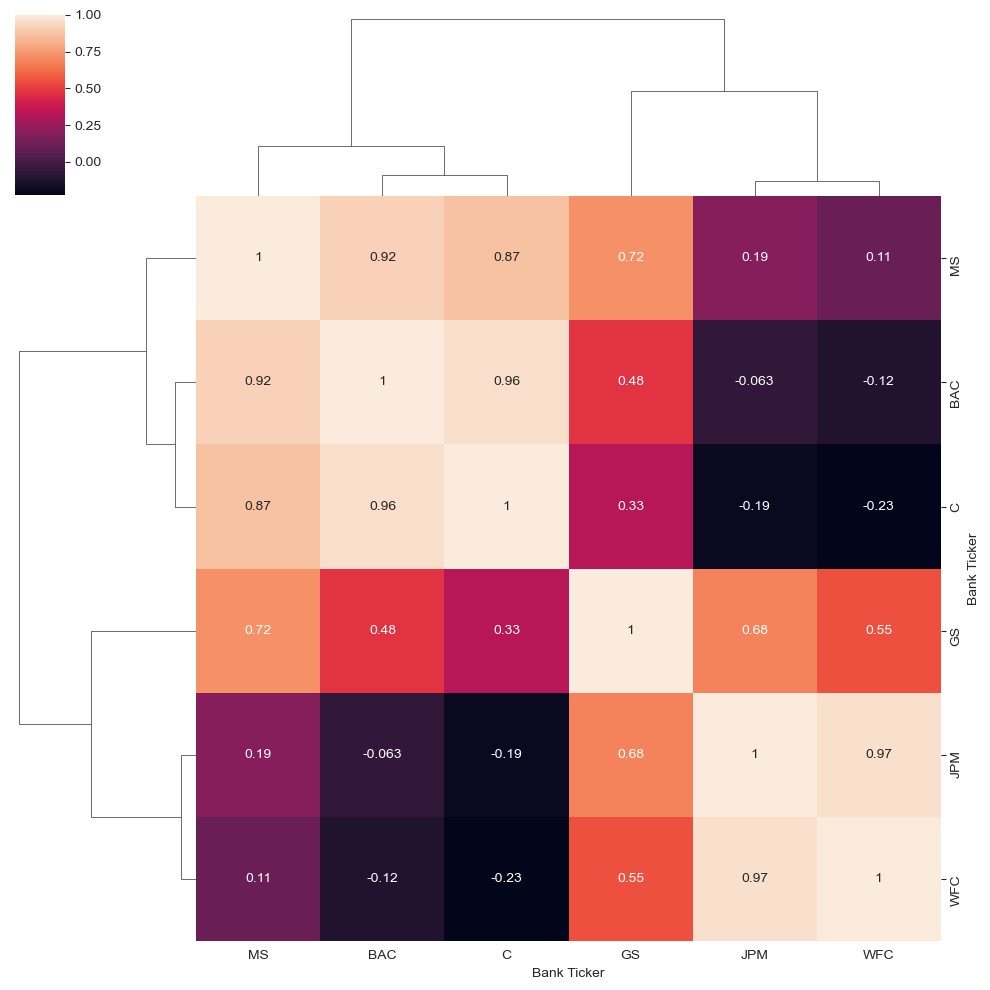

In [36]:
sns.clustermap(df.xs(key='Close',axis=1,level='Stock Info').corr(),annot=True)
plt.show()